# 🧪 Data Science Practical (Advanced)

## Experiment No: 1
## Experiment Title: Advanced Linear Algebra & PCA

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33  

---

##  Problem Statement

Perform advanced linear algebra operations including matrix operations, eigendecomposition, and rank analysis. Apply Principal Component Analysis (PCA) for dimensionality reduction on a real-world dataset and visualize the transformation.

---

##  Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import warnings 
warnings.filterwarnings('ignore')

np.random.seed(42)

## Part 1: Basic Matrix Operations 

In [2]:
A = np.array([
    [4, 7, 2, 1],
    [3, 5, 1, 8],
    [5, 2, 9, 3],
    [4, 6, 8, 7]
], dtype=float)

print("Matrix A: ")
print(A)

Matrix A: 
[[4. 7. 2. 1.]
 [3. 5. 1. 8.]
 [5. 2. 9. 3.]
 [4. 6. 8. 7.]]


In [3]:
det_A = np.linalg.det(A)
print(f"Determinant of A: {det_A:.4f}")

print(f"Is A matrix invertible? {
    'Yes' if abs(det_A) > 1e-10 else 'No'
    }")

Determinant of A: -1092.0000
Is A matrix invertible? Yes


In [4]:
A_inv = np.linalg.inv(A)
print("Inverse of A: ")
print(np.round(A_inv, 4))

identity_check = np.round(A @ A_inv, 8)
print("\nVerification A x A^-1 : ")
print(identity_check)

Inverse of A: 
[[ 0.0962  0.2225  0.3104 -0.4011]
 [ 0.1154 -0.1044 -0.1703  0.1758]
 [-0.0449 -0.1419 -0.0211  0.1777]
 [-0.1026  0.1245 -0.0073  0.0183]]

Verification A x A^-1 : 
[[ 1.  0.  0. -0.]
 [ 0.  1. -0. -0.]
 [ 0.  0.  1. -0.]
 [ 0.  0.  0.  1.]]


## Part 2: Advanced Matrix Properties

In [5]:
rank_A = np.linalg.matrix_rank(A)
print(f"Rank of A: {rank_A}")
print(f"Matrix Size: {A.shape[0]}X{A.shape[1]}")
print(f"Full Rank? {
    'Yes - all rows/cols are linearly independent' 
    if rank_A == min(A.shape) 
    else 'No - rank deficient'
    }")

Rank of A: 4
Matrix Size: 4X4
Full Rank? Yes - all rows/cols are linearly independent


In [6]:
eigen_values, eigen_vectors = np.linalg.eig(A)

print("Eigen Values: ")
for i, val in enumerate(eigen_values):
    print(f"λ{i + 1} = {val:.4f}")

print("\nEigenvectors (columns): ")
print(np.round(eigen_vectors, 4))


Eigen Values: 
λ1 = 18.9742+0.0000j
λ2 = 4.2151+2.4836j
λ3 = 4.2151-2.4836j
λ4 = -2.4044+0.0000j

Eigenvectors (columns): 
[[-0.3326+0.j      0.6756+0.j      0.6756-0.j      0.6825+0.j    ]
 [-0.4843+0.j      0.1752+0.3384j  0.1752-0.3384j -0.5906+0.j    ]
 [-0.4634+0.j     -0.3761-0.3797j -0.3761+0.3797j -0.2814+0.j    ]
 [-0.6634+0.j     -0.3286+0.0686j -0.3286-0.0686j  0.3259+0.j    ]]


In [7]:
print("Verification A.v = λ.v (residual should be approx. 0): ")
for i in range(len(eigen_values)):
    v = eigen_vectors[:, i]
    lv = eigen_values[i]
    res = np.linalg.norm(A @ v - lv * v)
    print(f" Eigenpair {i + 1} : residual = {res:.2e}")


Verification A.v = λ.v (residual should be approx. 0): 
 Eigenpair 1 : residual = 2.19e-14
 Eigenpair 2 : residual = 5.58e-15
 Eigenpair 3 : residual = 5.58e-15
 Eigenpair 4 : residual = 2.77e-15


## Part 3: Handling Singular Matrix

In [8]:
S = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=float)

print("Singular Matrix: S")
print(S)
print(f"\nDeterminant of S: {np.linalg.det(S):.6f}")


Singular Matrix: S
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Determinant of S: 0.000000


In [9]:
try:
    S_inv = np.linalg.inv(S)
    print("Inverse: ")
    print(S_inv)

except np.linalg.LinAlgError as e:
    print(f"[LinAlgError] Cannot invert singular matrix: {e}")

S_pinv = np.linalg.pinv(S)
print("\nPseudo-inverse (Moore-Penrose): ")
print(np.round(S_pinv, 4))
print(f"\nRank of S: {np.linalg.matrix_rank(S)} (rank-deficient - confirms singularity)")

[LinAlgError] Cannot invert singular matrix: Singular matrix

Pseudo-inverse (Moore-Penrose): 
[[-0.6389 -0.1667  0.3056]
 [-0.0556  0.      0.0556]
 [ 0.5278  0.1667 -0.1944]]

Rank of S: 2 (rank-deficient - confirms singularity)


## Part 4: PCA - Dimensionality Reduction on Iris Dataset

In [10]:
iris        = load_iris()
x           = iris.data
y           = iris.target
class_names = iris.target_names
feat_names  = iris.feature_names

print(f"Dataset Shape   : {x.shape}")
print(f"Features        : {feat_names}")
print(f"class_names     : {class_names}")
print(f"Samples / Class : {np.bincount(y)}")

Dataset Shape   : (150, 4)
Features        : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
class_names     : ['setosa' 'versicolor' 'virginica']
Samples / Class : [50 50 50]


In [11]:
scaler = StandardScaler()
x_std = scaler.fit_transform(x)

print("After Standardization: ")
print(f" Mean per features : {np.round(x_std.mean(axis=0), 6)}")
print(f" Std  per Features : {np.round(x_std.std(axis=0),  4)}")

After Standardization: 
 Mean per features : [-0. -0. -0. -0.]
 Std  per Features : [1. 1. 1. 1.]


In [12]:
pca     = PCA(n_components=2)
x_pca   = pca.fit_transform(x_std)

print(f"Original shape  : {x_std.shape}")
print(f"Reduced  shape  : {x_pca.shape}")
print(f"\nExplained Variance Ratio: ")

for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev*100:.2f}")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}% variance retained")

Original shape  : (150, 4)
Reduced  shape  : (150, 2)

Explained Variance Ratio: 
  PC1: 72.96
  PC2: 22.85
  Total: 95.81% variance retained


In [13]:
print("PCA Component Loadings: ")
print(f"{'Feature':<30} {'PC1':>8} {'PC2':>8}")
print("-"*48)
for feat, pc1, pc2 in zip(feat_names, pca.components_[0],pca.components_[1]):
    print(f"{feat:<30} {pc1:>8.4f} {pc2:>8.4f}")


PCA Component Loadings: 
Feature                             PC1      PC2
------------------------------------------------
sepal length (cm)                0.5211   0.3774
sepal width (cm)                -0.2693   0.9233
petal length (cm)                0.5804   0.0245
petal width (cm)                 0.5649   0.0669


## Part 5: Visualization

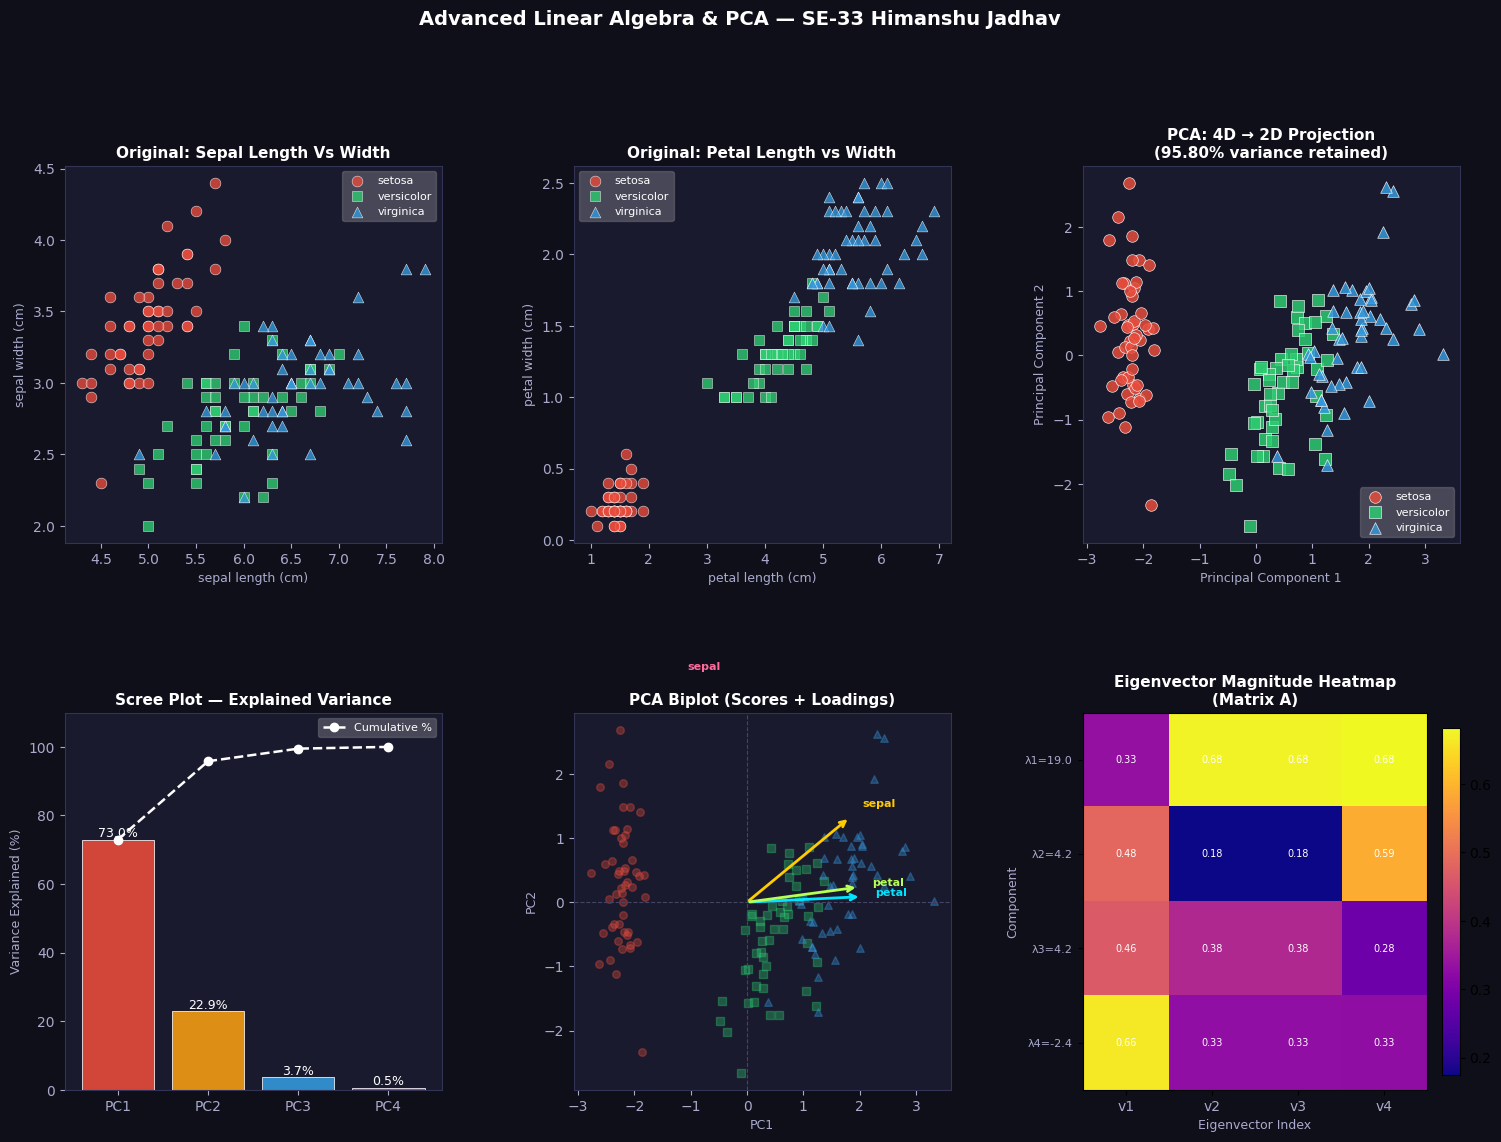

✅ Plot saved as LA_PCA_results.png


In [14]:
colors  = ['#e74c3c', '#2ecc71', '#3498db']
markers = ['o', 's', '^']

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0f0f1a")
gs  = gridspec.GridSpec(2,3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#1a1a2e")

for cls, col, mrk in zip(range(3), colors, markers):
    mask = y == cls
    ax1.scatter(x[mask, 0], x[mask, 1], c=col, marker=mrk,
                label=class_names[cls], alpha=0.8, s=60, edgecolors='white', lw=0.4)
    
ax1.set_title('Original: Sepal Length Vs Width', color='white', fontsize=11, fontweight='bold')
ax1.set_xlabel(feat_names[0], color="#aaaacc", fontsize=9)
ax1.set_ylabel(feat_names[1], color='#aaaacc', fontsize=9)
ax1.tick_params(colors="#aaaacc")
ax1.spines[:].set_color('#333355')
ax1.legend(fontsize=8, framealpha=0.2, labelcolor='white')

# Plot 2 

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a2e')

for cls, col, mrk in zip(range(3), colors, markers):
    mask = y == cls
    ax2.scatter(x[mask, 2], x[mask, 3], c=col, marker= mrk,
                label=class_names[cls], alpha=0.8, s=60, edgecolors='white', lw=0.4)
    
ax2.set_title('Original: Petal Length vs Width', color='white', fontsize=11, fontweight='bold')
ax2.set_xlabel(feat_names[2], color='#aaaacc', fontsize=9)
ax2.set_ylabel(feat_names[3], color='#aaaacc', fontsize=9)
ax2.tick_params(colors='#aaaacc')
ax2.spines[:].set_color('#333355')
ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white')

# Plot 3 — PCA 2D Projection (main result)

ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a2e')

for cls, col, mrk in zip(range(3), colors, markers):
    mask = y == cls
    ax3.scatter(x_pca[mask, 0], x_pca[mask, 1], c=col, marker=mrk,
                label=class_names[cls], alpha=0.85, s=70, edgecolors='white', lw=0.5)

ax3.set_title('PCA: 4D → 2D Projection\n(95.80% variance retained)', 
              color='white', fontsize=11, fontweight='bold')
ax3.set_xlabel('Principal Component 1', color='#aaaacc', fontsize=9)
ax3.set_ylabel('Principal Component 2', color='#aaaacc', fontsize=9)
ax3.tick_params(colors='#aaaacc')
ax3.spines[:].set_color('#333355')
ax3.legend(fontsize=8, framealpha=0.2, labelcolor='white')

# Plot 4 — Explained Variance (Scree Plot)

pca_full     = PCA().fit(x_std)   
cumvar        = np.cumsum(pca_full.explained_variance_ratio_) * 100
indiv_var     = pca_full.explained_variance_ratio_ * 100
pc_labels     = [f'PC{i+1}' for i in range(4)]

ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#1a1a2e')

bars = ax4.bar(pc_labels, indiv_var, color=['#e74c3c','#f39c12','#3498db','#9b59b6'],
               edgecolor='white', linewidth=0.6, alpha=0.9)
ax4.plot(pc_labels, cumvar, 'w--o', linewidth=1.8, markersize=6, label='Cumulative %')

for bar, v in zip(bars, indiv_var):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{v:.1f}%', ha='center', color='white', fontsize=9)

ax4.set_title('Scree Plot — Explained Variance', color='white', fontsize=11, fontweight='bold')
ax4.set_ylabel('Variance Explained (%)', color='#aaaacc', fontsize=9)
ax4.set_ylim(0, 110)
ax4.tick_params(colors='#aaaacc')
ax4.spines[:].set_color('#333355')
ax4.legend(fontsize=8, framealpha=0.2, labelcolor='white')

# Plot 5 — PCA Biplot (loadings overlaid on scores)

ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('#1a1a2e')

for cls, col, mrk in zip(range(3), colors, markers):
    mask = y == cls
    ax5.scatter(x_pca[mask, 0], x_pca[mask, 1], c=col, marker=mrk,
                alpha=0.35, s=30)

scale = 3.5
arrow_colors = ['#ffcc00','#ff6b9d','#00e5ff','#b8ff55']
for i, (feat, ac) in enumerate(zip(feat_names, arrow_colors)):
    ax5.annotate('', xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                 xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=ac, lw=2))
    ax5.text(pca.components_[0,i]*scale*1.12, pca.components_[1,i]*scale*1.12,
             feat.split(' ')[0], color=ac, fontsize=8, fontweight='bold')

ax5.axhline(0, color='#444466', lw=0.8, ls='--')
ax5.axvline(0, color='#444466', lw=0.8, ls='--')
ax5.set_title('PCA Biplot (Scores + Loadings)', color='white', fontsize=11, fontweight='bold')
ax5.set_xlabel('PC1', color='#aaaacc', fontsize=9)
ax5.set_ylabel('PC2', color='#aaaacc', fontsize=9)
ax5.tick_params(colors='#aaaacc')
ax5.spines[:].set_color('#333355')

# Plot 6 — Eigenvalue heatmap of matrix A

ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1a2e')

im = ax6.imshow(np.abs(eigen_vectors.real), cmap='plasma', aspect='auto')
plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)

ax6.set_title('Eigenvector Magnitude Heatmap\n(Matrix A)', color='white', fontsize=11, fontweight='bold')
ax6.set_xlabel('Eigenvector Index', color='#aaaacc', fontsize=9)
ax6.set_ylabel('Component', color='#aaaacc', fontsize=9)
ax6.set_xticks(range(4))
ax6.set_xticklabels([f'v{i+1}' for i in range(4)], color='#aaaacc')
ax6.set_yticks(range(4))
ax6.set_yticklabels([f'λ{i+1}={eigen_values[i].real:.1f}' for i in range(4)], color='#aaaacc', fontsize=8)

# Annotate cells
for i in range(4):
    for j in range(4):
        ax6.text(j, i, f'{np.abs(eigen_vectors[i,j].real):.2f}',
                 ha='center', va='center', color='white', fontsize=7)

# ─────────────────────────────────────────────────────────────────────────────
# Overall title
fig.suptitle('Advanced Linear Algebra & PCA — SE-33 Himanshu Jadhav',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.savefig('LA_PCA_results.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Plot saved as LA_PCA_results.png")